# Global Conflict & Economic Impact Analysis

## Phase 4 - Inflation Analysis

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [ ]:
inflation_df = pd.read_csv("clean_inflation.csv")

inflation_df.head()

,Country Name,Country Code,Year,Inflation_Rate
0,Aruba,ABW,2000,4.044021
1,Africa Eastern and Southern,AFE,2000,8.601485
2,Afghanistan,AFG,2000,NaN
3,Africa Western and Central,AFW,2000,2.530775
4,Angola,AGO,2000,324.996872


In [ ]:
print("Shape :", inflation_df.shape)

inflation_df.info()

Shape : (6650, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6650 entries, 0 to 6649
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    6650 non-null   object 
 1   Country Code    6650 non-null   object 
 2   Year            6650 non-null   int64  
 3   Inflation_Rate  4569 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 207.9+ KB


In [ ]:
inflation_df.isnull().sum()

,0
Country Name,0
Country Code,0
Year,0
Inflation_Rate,2081


In [ ]:
inflation_df["Year"] = inflation_df["Year"].astype(int)

inflation_df["Inflation_Rate"] = pd.to_numeric(
    inflation_df["Inflation_Rate"],
    errors="coerce"
)

In [ ]:
inflation_df.describe()

,Year,Inflation_Rate
count,6650.000000,4569.000000
mean,2012.000000,6.726060
std,7.211645,19.827256
min,2000.000000,-16.859691
25%,2006.000000,1.634855
50%,2012.000000,3.523173
75%,2018.000000,7.052982
max,2024.000000,557.201817


In [ ]:
global_inflation = (
    inflation_df
    .groupby("Year")["Inflation_Rate"]
    .mean()
    .reset_index()
)

global_inflation.head()

,Year,Inflation_Rate
0,2000,13.002068
1,2001,9.660457
2,2002,6.217576
3,2003,5.971641
4,2004,5.259240


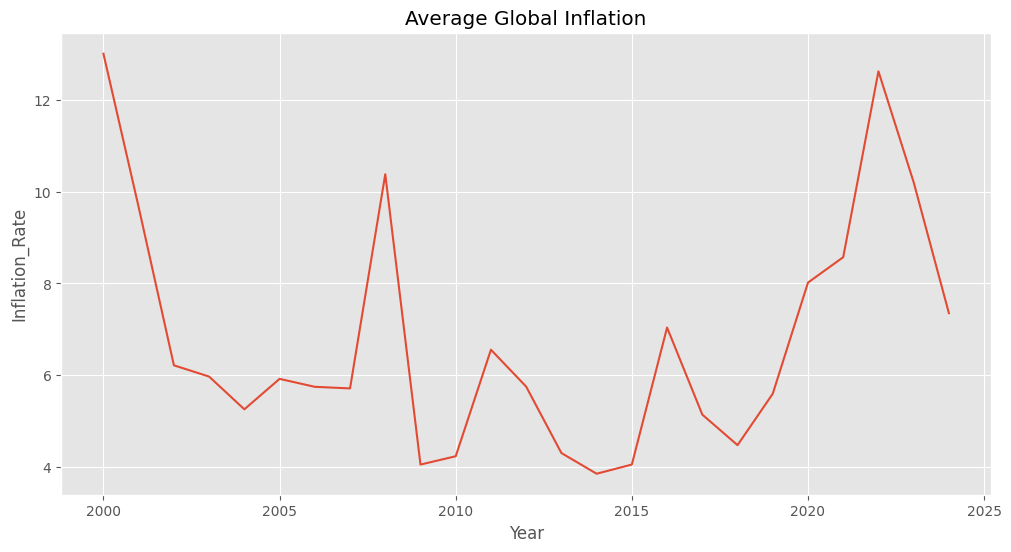

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=global_inflation,
    x="Year",
    y="Inflation_Rate"
)

plt.title("Average Global Inflation")

plt.show()

In [ ]:
fig = px.line(
    global_inflation,
    x="Year",
    y="Inflation_Rate",
    title="Global Inflation Trend"
)

fig.show()

In [ ]:
latest_year = inflation_df["Year"].max()

latest = inflation_df[
    inflation_df["Year"] == latest_year
]

latest.head()

,Country Name,Country Code,Year,Inflation_Rate
6384,Aruba,ABW,2024,NaN
6385,Africa Eastern and Southern,AFE,2024,4.770857
6386,Afghanistan,AFG,2024,-6.601186
6387,Africa Western and Central,AFW,2024,3.608044
6388,Angola,AGO,2024,28.240495


In [ ]:
top10 = (
    latest
    .sort_values(
        "Inflation_Rate",
        ascending=False
    )
    .head(10)
)

top10

,Country Name,Country Code,Year,Inflation_Rate
6393,Argentina,ARG,2024,219.883929
6600,South Sudan,SSD,2024,91.440822
6628,Turkiye,TUR,2024,58.506451
6580,West Bank and Gaza,PSE,2024,53.669146
6514,Lebanon,LBN,2024,45.243042
6558,Nigeria,NGA,2024,33.242097
6496,"Iran, Islamic Rep.",IRN,2024,32.455871
6552,Malawi,MWI,2024,32.179650
6594,Sierra Leone,SLE,2024,28.633750
6451,"Egypt, Arab Rep.",EGY,2024,28.270590


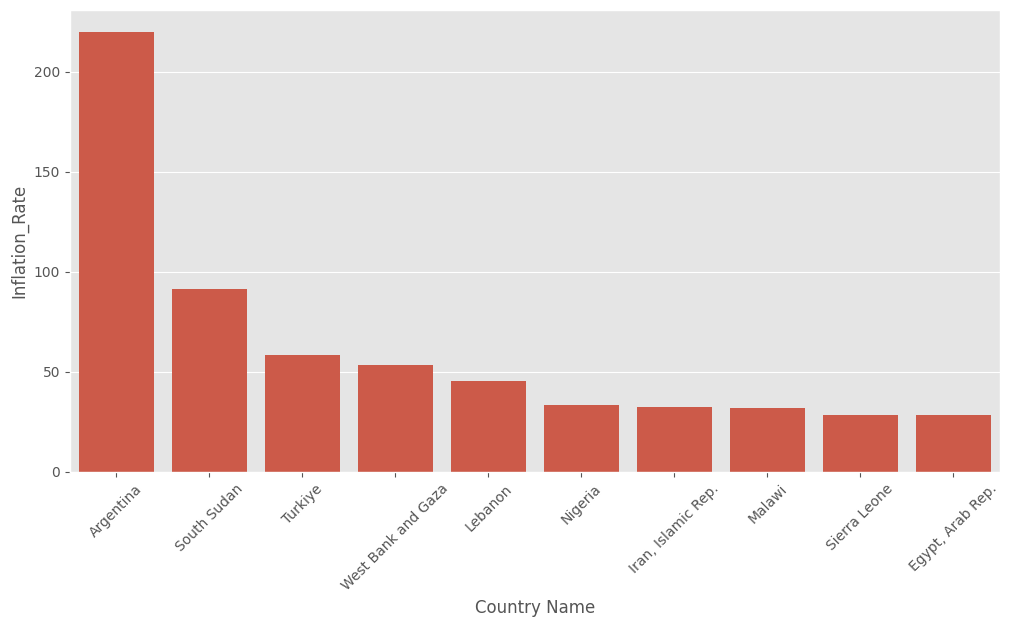

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Country Name",
    y="Inflation_Rate"
)

plt.xticks(rotation=45)

plt.show()

In [ ]:
fig = px.bar(
    top10,
    x="Country Name",
    y="Inflation_Rate",
    title="Top Inflation Countries"
)

fig.show()

In [ ]:
lowest10 = (
    latest
    .sort_values("Inflation_Rate")
    .head(10)
)

lowest10

,Country Name,Country Code,Year,Inflation_Rate
6497,Iraq,IRQ,2024,-12.296984
6386,Afghanistan,AFG,2024,-6.601186
6522,Sri Lanka,LKA,2024,-0.429360
6432,Costa Rica,CRI,2024,-0.412853
6415,Brunei Darussalam,BRN,2024,-0.388674
6517,St. Lucia,LCA,2024,-0.110284
6424,China,CHN,2024,0.218129
6394,Armenia,ARM,2024,0.269512
6610,Seychelles,SYC,2024,0.311726
6407,"Bahamas, The",BHS,2024,0.409162


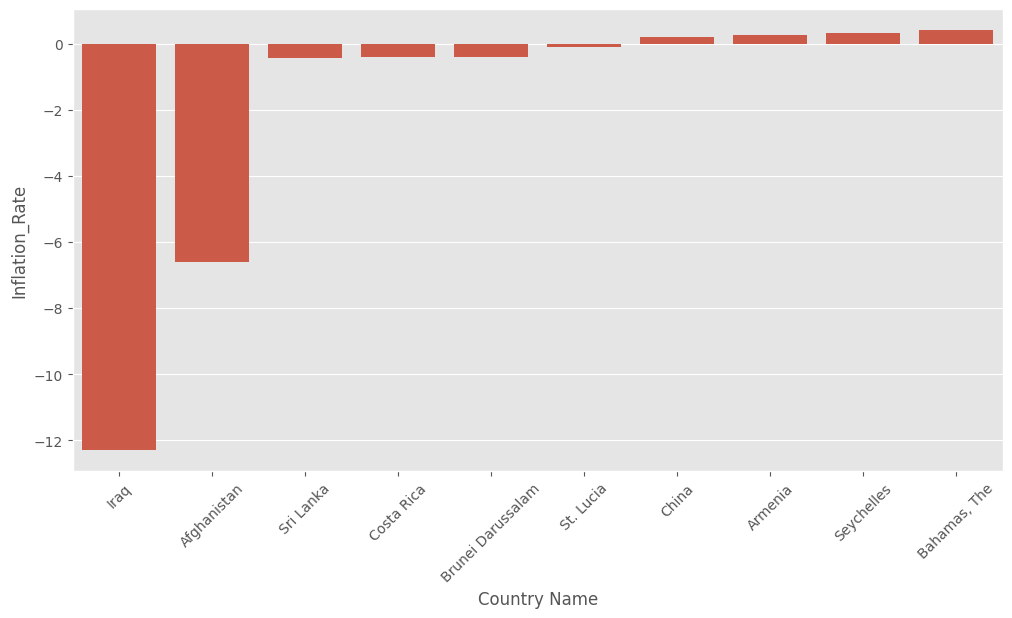

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=lowest10,
    x="Country Name",
    y="Inflation_Rate"
)

plt.xticks(rotation=45)

plt.show()

In [ ]:
countries = [
    "United States",
    "China",
    "India",
    "Russia",
    "Germany"
]

major = inflation_df[
    inflation_df["Country Name"].isin(countries)
]

major.head()

,Country Name,Country Code,Year,Inflation_Rate
40,China,CHN,2000,0.347811
55,Germany,DEU,2000,1.440268
109,India,IND,2000,4.009436
251,United States,USA,2000,3.376857
306,China,CHN,2001,0.719126


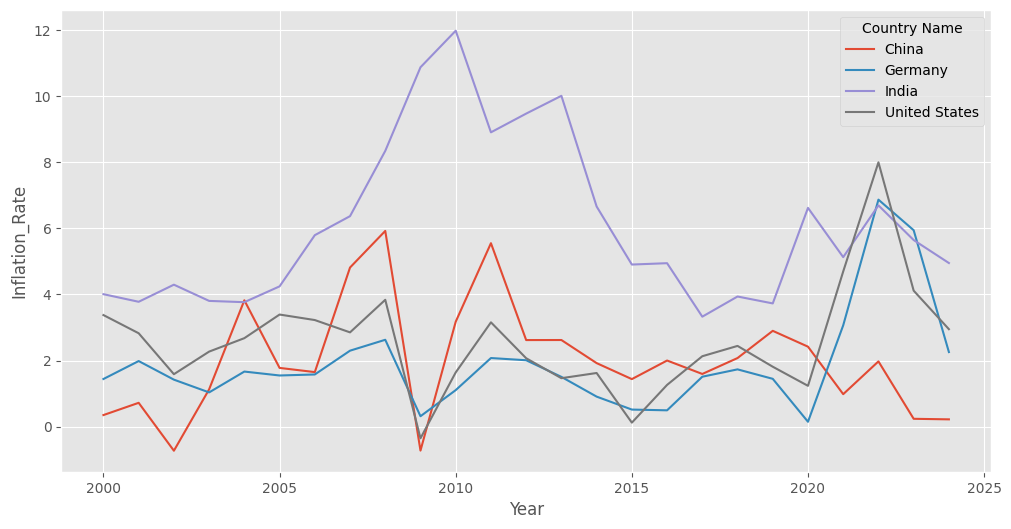

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=major,
    x="Year",
    y="Inflation_Rate",
    hue="Country Name"
)

plt.show()

In [ ]:
fig = px.line(
    major,
    x="Year",
    y="Inflation_Rate",
    color="Country Name",
    title="Inflation Trend of Major Economies"
)

fig.show()

In [ ]:
volatility = (
    inflation_df
    .groupby("Country Name")["Inflation_Rate"]
    .std()
    .sort_values(ascending=False)
)

volatility.head(15)

,Inflation_Rate
Country Name,
Zimbabwe,161.785617
"Congo, Dem. Rep.",144.450581
South Sudan,98.615804
"Venezuela, RB",80.763089
Sudan,79.103318
Lebanon,73.127488
Angola,68.644172
Argentina,67.626070
Belarus,34.546721


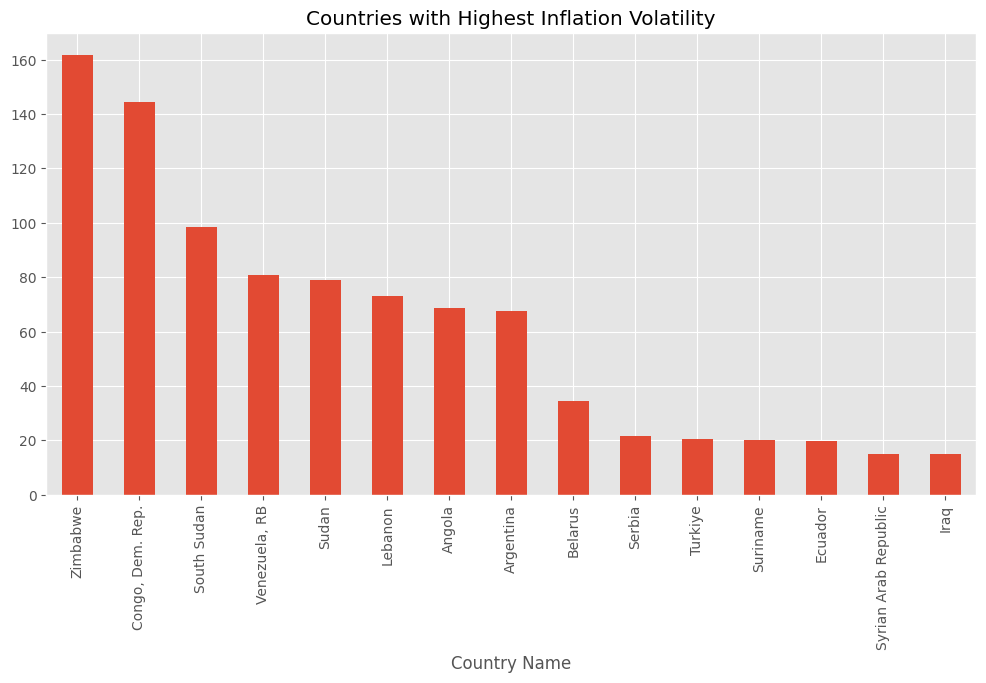

In [ ]:
plt.figure(figsize=(12,6))

volatility.head(15).plot(kind="bar")

plt.title("Countries with Highest Inflation Volatility")

plt.show()

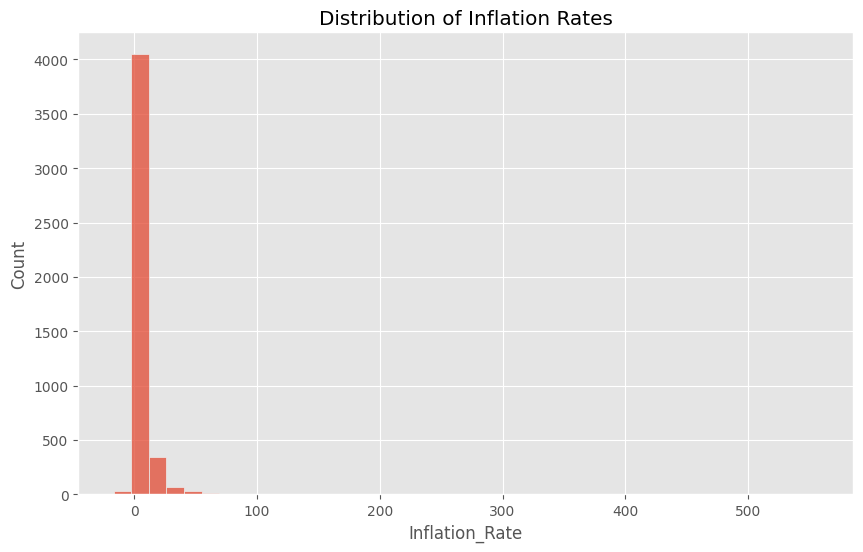

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    inflation_df["Inflation_Rate"],
    bins=40
)

plt.title("Distribution of Inflation Rates")

plt.show()

In [ ]:
country_avg = (
    inflation_df
    .groupby("Country Name")["Inflation_Rate"]
    .mean()
    .sort_values(ascending=False)
)

country_avg.head(20)

,Inflation_Rate
Country Name,
Argentina,86.293375
Zimbabwe,79.611351
"Venezuela, RB",72.740289
South Sudan,63.678718
"Congo, Dem. Rep.",60.674708
Sudan,47.215696
Lebanon,44.355562
Angola,43.003865
Belarus,24.473539


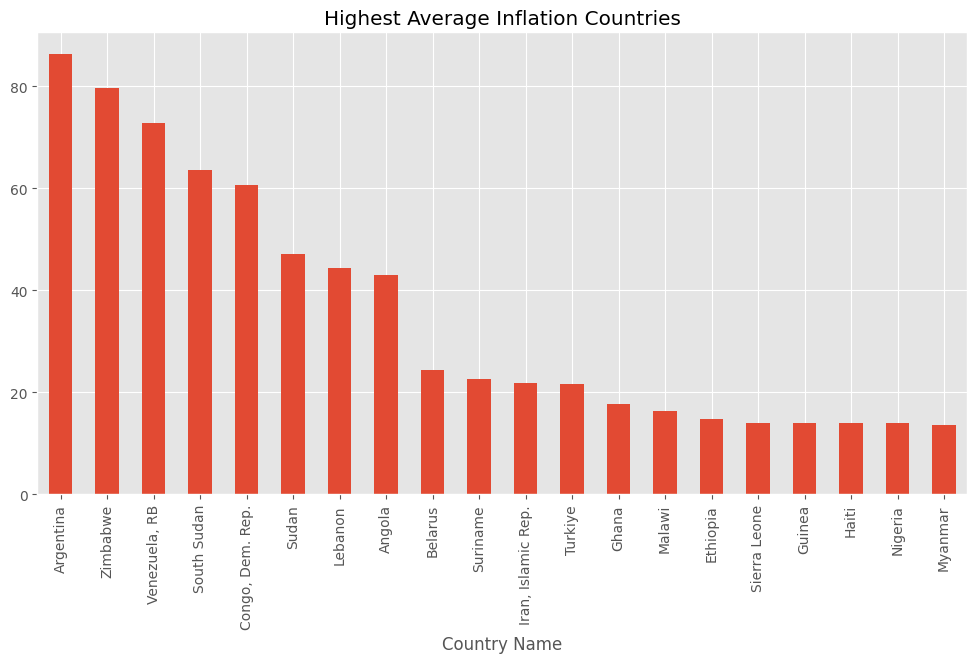

In [ ]:
plt.figure(figsize=(12,6))

country_avg.head(20).plot(kind="bar")

plt.title("Highest Average Inflation Countries")

plt.show()

In [ ]:
print(f"""

Latest Year :
{latest_year}

Highest Inflation Country :
{top10.iloc[0]['Country Name']}

Highest Inflation :
{top10.iloc[0]['Inflation_Rate']:.2f}

Lowest Inflation Country :
{lowest10.iloc[0]['Country Name']}

Countries Covered :
{inflation_df['Country Name'].nunique()}

""")



Latest Year :
2024

Highest Inflation Country :
Argentina

Highest Inflation :
219.88

Lowest Inflation Country :
Iraq

Countries Covered :
266




In [ ]:
global_inflation.to_csv(
    "global_inflation_trend.csv",
    index=False
)

top10.to_csv(
    "top10_inflation.csv",
    index=False
)

country_avg.reset_index().to_csv(
    "average_country_inflation.csv",
    index=False
)

print("Phase 4 Completed Successfully")

Phase 4 Completed Successfully
